In [1]:
# в терминале mlflow ui

In [ ]:
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score
import joblib
from tqdm import tqdm
import time

/home/margo/A/projects/python/client_activity_forecast/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path = "../models"

In [11]:
version = 4
df = pd.read_parquet(f"../data/processed/client_month_features_{version}.parquet")
df = df.sort_values(['year_month'])

# Подготовка данных
months = sorted(df['year_month'].unique())
n_months = len(months)

# 70% train, 15% val, 15% test
train_months = months[:int(n_months * 0.7)]                     # первые 70%
val_months = months[int(n_months * 0.7):int(n_months * 0.85)]   # следующие 15%
test_months = months[int(n_months * 0.85):]                     # последние 15%

train = df[df['year_month'].isin(train_months)]
val = df[df['year_month'].isin(val_months)]
test = df[df['year_month'].isin(test_months)]

exclude = ['client_id', 'year_month', 'amount_11_sum']
target = 'amount_11_sum'

# forward feature selection

In [17]:
all_features = list(df.columns)
features_to_analyze = all_features[:-3]
target = all_features[-1]

In [18]:
features_to_analyze

['lag12_amount_11_sum',
 'amount_11_sum_rolling_min_6m',
 'amount_11_sum_rolling_max_6m',
 'amount_11_hist_cv_lag',
 'lag3_amount_11_sum',
 'amount_11_abs_change_lag',
 'lag9_amount_11_median',
 'lag2_amount_11_sum',
 'amount_11_sum_rolling_min_3m',
 'lag6_amount_11_sum',
 'lag9_tx_11_count',
 'amount_11_consecutive_growth_lag',
 'src_type12_n_unique',
 'amount_11_is_spike_lag',
 'lag3_amount_11_std',
 'amount_11_vs_3m_avg_lag',
 'lag1_amount_11_median',
 'amount_11_vs_hist_max_lag',
 'is_quarter_end',
 'tx_11_share_cum',
 'src_type11_n_unique',
 'lag12_amount_11_std',
 'amount_11_is_dip_lag',
 'lag1_amount_11_sum',
 'lag6_amount_11_mean',
 'amount_11_hist_mean',
 'lag9_amount_11_std',
 'amount_11_sum_rolling_min_12m',
 'lag3_amount_11_mean',
 'lag12_amount_11_median',
 'amount_11_is_zero_lag',
 'amount_11_sum_rolling_max_12m',
 'lag2_amount_11_mean',
 'amount_11_vs_hist_min_lag',
 'lag12_tx_11_count',
 'lag2_amount_11_median',
 'lag6_amount_11_median',
 'tx_11_cumsum',
 'lag2_amount_1

Проверка признаков:   2%|▏         | 1/56 [00:01<01:02,  1.13s/it, val_r2=0.0629, best=0.0629, selected=1, no_improve=0]

🏃 View run step_1 at: http://127.0.0.1:5000/#/experiments/4/runs/b085fafcf6a54249b739bc7ca1f7f7b4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Проверка признаков:   4%|▎         | 2/56 [00:02<00:58,  1.09s/it, val_r2=0.0750, best=0.0750, selected=2, no_improve=0]

🏃 View run step_2 at: http://127.0.0.1:5000/#/experiments/4/runs/1d78f8f3fb714ccfa2d05b10d698d822
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Проверка признаков:   5%|▌         | 3/56 [00:03<00:54,  1.03s/it, val_r2=0.0930, best=0.0930, selected=3, no_improve=0]

...

🏃 View run step_54 at: http://127.0.0.1:5000/#/experiments/4/runs/1f7b3fd048b04dea8985e6833c160893
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Проверка признаков:  98%|█████████▊| 55/56 [00:55<00:01,  1.14s/it, val_r2=0.4938, best=0.5014, selected=19, no_improve=7]

🏃 View run step_55 at: http://127.0.0.1:5000/#/experiments/4/runs/077c40bd1ffe42b7b526601abf83c372
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Проверка признаков: 100%|██████████| 56/56 [00:56<00:00,  1.01s/it, val_r2=0.5014, best=0.5014, selected=19, no_improve=8]

🏃 View run step_56 at: http://127.0.0.1:5000/#/experiments/4/runs/9973687db3344c48af4f257e315de492
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


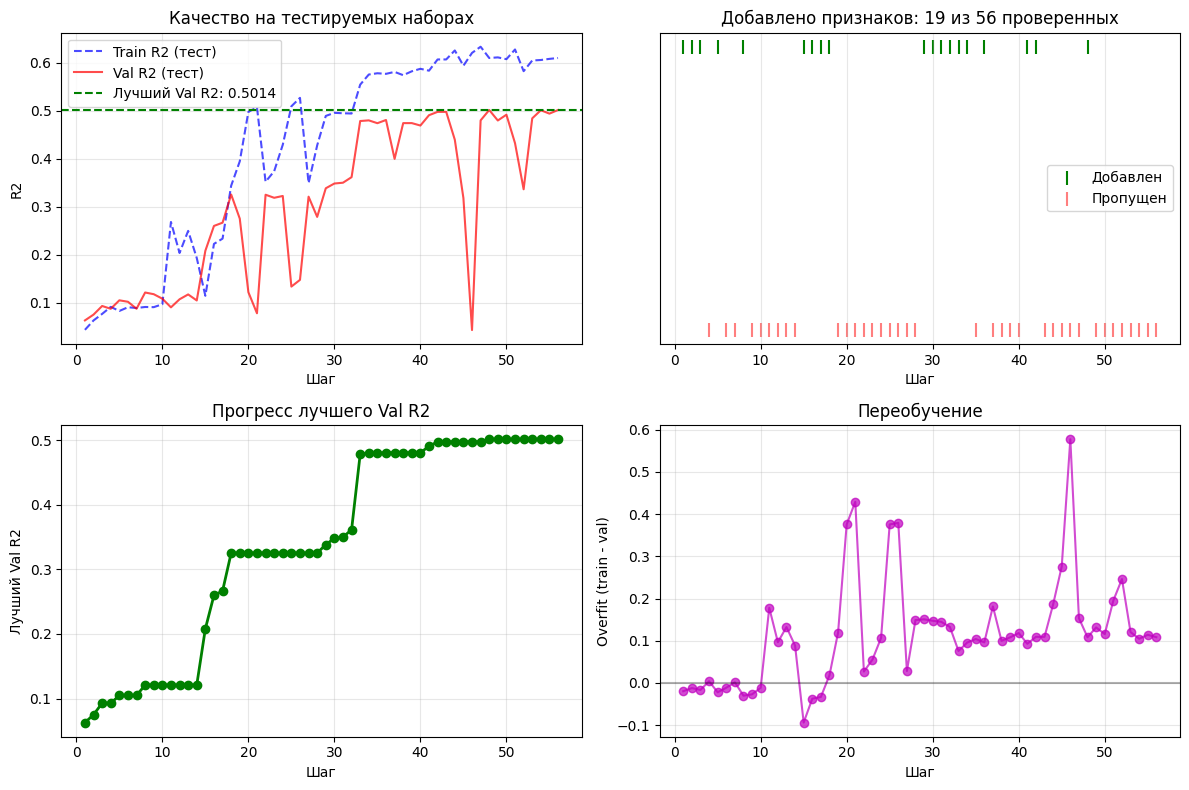


РЕЗУЛЬТАТЫ:
Лучших признаков: 19
Лучший Val R2: 0.5014
Всего проверено: 56 признаков
Процент отобранных: 33.9%

Лучшие признаки:
 1. lag1_amount_11_sum
 2. lag1_amount_11_std
 3. amount_11_sum_rolling_max_3m
 4. amount_11_sum_rolling_max_6m
 5. amount_11_hist_mean
 6. lag12_amount_11_sum
 7. lag9_amount_11_sum
 8. amount_11_sum_rolling_min_12m
 9. amount_11_vs_cummean_lag
10. src_type12_n_unique
    ... и еще 9
🏃 View run fwd_selection_1772457407 at: http://127.0.0.1:5000/#/experiments/4/runs/470bf4b4ca2e4b54959f6a0760413552
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


In [ ]:
# Настройка MLflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("forward_feature_selection_v4")

def forward_feature_selection(
    train_df,
    val_df,
    target_col,
    feature_cols,
    model_class=LGBMRegressor,
    model_params=None,
    stopping_rounds=10,
    improvement_threshold=0.001,
    artifact_path=path
):
    """
    Forward feature selection с отслеживанием в MLflow
    Добавляются только признаки, улучшающие качество на валидации
    """
    # Сортируем признаки по корреляции с target
    correlations = []
    for f in feature_cols:
        corr = train_df[f].corr(train_df[target_col])
        correlations.append((f, abs(corr)))
    
    sorted_features = [f for f, _ in sorted(correlations, key=lambda x: x[1], reverse=True)]
    
    # Подготовка данных
    X_train_full = train_df[sorted_features]
    y_train = train_df[target_col]
    X_val_full = val_df[sorted_features]
    y_val = val_df[target_col]
    
    # Инициализация
    current_features = []  # текущий набор признаков
    results = []
    best_val_r2 = -np.inf
    best_features = []
    no_improve_count = 0
    
    # Создаем уникальный ID для эксперимента
    exp_id = f"fwd_selection_{int(time.time())}"
    
    with mlflow.start_run(run_name=exp_id):
        
        # Логируем общие параметры
        mlflow.log_params({
            "n_features_total": len(sorted_features),
            "stopping_rounds": stopping_rounds,
            "improvement_threshold": improvement_threshold,
            "model": model_class.__name__,
            "model_params": str(model_params)
        })
        
        # Основной цикл
        pbar = tqdm(total=len(sorted_features), desc="Проверка признаков")
        
        for i, feature in enumerate(sorted_features):
            
            # Пробуем добавить признак
            test_features = current_features + [feature]
            
            # Обучаем модель на тестовом наборе
            model = model_class(**model_params) if model_params else model_class()
            model.fit(X_train_full[test_features], y_train)
            
            # Предсказания
            train_pred = model.predict(X_train_full[test_features])
            val_pred = model.predict(X_val_full[test_features])
            
            # Метрики
            train_r2 = r2_score(y_train, train_pred)
            val_r2 = r2_score(y_val, val_pred)
            overfit = train_r2 - val_r2
            
            # Логируем в MLflow (вложенный run для каждого шага)
            with mlflow.start_run(run_name=f"step_{i+1}", nested=True):
                
                mlflow.log_params({
                    "step": i+1,
                    "feature_tested": feature,
                    "n_features_tested": len(test_features)
                })
                
                mlflow.log_metrics({
                    "train_r2": train_r2,
                    "val_r2": val_r2,
                    "overfit": overfit
                })
                
                # Проверяем, улучшает ли признак
                if val_r2 > best_val_r2 + improvement_threshold:
                    # ДА - добавляем
                    current_features.append(feature)
                    best_val_r2 = val_r2
                    best_features = current_features.copy()
                    no_improve_count = 0
                    action = "ДОБАВЛЕН"
                    
                    # Сохраняем лучшую модель
                    model_path = f"{artifact_path}/best_model_step_{len(current_features)}.pkl"
                    joblib.dump(model, model_path)
                    mlflow.log_artifact(model_path)
                    mlflow.log_metric("best_val_r2", best_val_r2)
                    
                else:
                    # НЕТ - пропускаем
                    no_improve_count += 1
                    action = "ПРОПУЩЕН"
                
                # Сохраняем результаты
                results.append({
                    'step': i+1,
                    'feature_tested': feature,
                    'action': action,
                    'n_features_current': len(current_features),
                    'train_r2': train_r2,
                    'val_r2': val_r2,
                    'overfit': overfit,
                    'best_val_r2_so_far': best_val_r2
                })
            
            # Обновляем прогресс
            pbar.update(1)
            pbar.set_postfix({
                'val_r2': f'{val_r2:.4f}',
                'best': f'{best_val_r2:.4f}',
                'selected': len(current_features),
                'no_improve': no_improve_count
            })
            
            # Проверка на остановку
            if no_improve_count >= stopping_rounds:
                print(f"\nОстановка: нет улучшения {stopping_rounds} шагов подряд")
                break
        
        pbar.close()
        
        # Создаем DataFrame с результатами
        results_df = pd.DataFrame(results)
        
        # Сохраняем результаты
        results_path = f"{artifact_path}/selection_results.csv"
        results_df.to_csv(results_path, index=False)
        mlflow.log_artifact(results_path)
        
        # Строим график
        plt.figure(figsize=(12, 8))
        
        # График R2 на тестируемых наборах
        plt.subplot(2, 2, 1)
        plt.plot(results_df['step'], results_df['train_r2'], 'b--', alpha=0.7, label='Train R2 (тест)')
        plt.plot(results_df['step'], results_df['val_r2'], 'r-', alpha=0.7, label='Val R2 (тест)')
        plt.axhline(y=best_val_r2, color='g', linestyle='--', label=f'Лучший Val R2: {best_val_r2:.4f}')
        plt.xlabel('Шаг')
        plt.ylabel('R2')
        plt.title('Качество на тестируемых наборах')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # График Накопление признаков
        plt.subplot(2, 2, 2)
        added_steps = [r['step'] for r in results if 'ДОБАВЛЕН' in r['action']]
        plt.scatter(added_steps, [1]*len(added_steps), marker='|', s=100, color='g', label='Добавлен')
        plt.scatter([r['step'] for r in results if 'ПРОПУЩЕН' in r['action']], 
                   [0]*len([r for r in results if 'ПРОПУЩЕН' in r['action']]), 
                   marker='|', s=100, color='r', alpha=0.5, label='Пропущен')
        plt.xlabel('Шаг')
        plt.yticks([])
        plt.title(f'Добавлено признаков: {len(best_features)} из {len(results_df)} проверенных')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # График Лучший Val R2 по ходу отбора
        plt.subplot(2, 2, 3)
        best_progression = []
        for j in range(len(results_df)):
            best_progression.append(max(results_df['best_val_r2_so_far'].iloc[:j+1]))
        plt.plot(results_df['step'], best_progression, 'g-o', linewidth=2)
        plt.xlabel('Шаг')
        plt.ylabel('Лучший Val R2')
        plt.title('Прогресс лучшего Val R2')
        plt.grid(True, alpha=0.3)
        
        # График Overfit (разница train-val)
        plt.subplot(2, 2, 4)
        plt.plot(results_df['step'], results_df['overfit'], 'm-o', alpha=0.7)
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.xlabel('Шаг')
        plt.ylabel('Overfit (train - val)')
        plt.title('Переобучение')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Сохраняем график
        plot_path = f"{artifact_path}/selection_plot.png"
        plt.savefig(plot_path, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(plot_path)
        plt.show()
        
        # Логируем итоговые метрики
        mlflow.log_metrics({
            "final_n_features": len(best_features),
            "best_val_r2": best_val_r2,
            "total_tested": len(results_df),
            "stopped_at_step": len(results_df)
        })
        
        # Сохраняем лучшие признаки
        best_features_path = f"{artifact_path}/best_features.txt"
        with open(best_features_path, 'w') as f:
            for feat in best_features:
                f.write(f"{feat}\n")
        mlflow.log_artifact(best_features_path)
        
        print("\n" + "="*60)
        print("РЕЗУЛЬТАТЫ:")
        print("="*60)
        print(f"Лучших признаков: {len(best_features)}")
        print(f"Лучший Val R2: {best_val_r2:.4f}")
        print(f"Всего проверено: {len(results_df)} признаков")
        print(f"Процент отобранных: {len(best_features)/len(results_df)*100:.1f}%")
        print("\nЛучшие признаки:")
        for i, feat in enumerate(best_features[:10]):
            print(f"{i+1:2d}. {feat}")
        if len(best_features) > 10:
            print(f"    ... и еще {len(best_features)-10}")
        
        return best_features, results_df

# Использование
best_features, results = forward_feature_selection(
    train_df=train,
    val_df=val,
    target_col='amount_11_sum',
    feature_cols=features_to_analyze,  
    model_class=LGBMRegressor,
    model_params={
        'n_estimators': 100,
        'learning_rate': 0.05,
        'random_state': 42,
        'verbose': -1
    },
    stopping_rounds=15,  # увеличено, чтобы не останавливаться рано
    improvement_threshold=0.0005  # снижено для более тонкого отбора
)

In [8]:
with open('../mlartifacts/4/470bf4b4ca2e4b54959f6a0760413552/artifacts/best_features.txt', 'r') as f:
    best_features = [line.strip() for line in f.readlines()]

print(f"Лучших признаков: {len(best_features)}")
print("\nСписок лучших признаков:")
for i, feat in enumerate(best_features, 1):
    print(f"{i:2d}. {feat}")

Лучших признаков: 19

Список лучших признаков:
 1. lag1_amount_11_sum
 2. lag1_amount_11_std
 3. amount_11_sum_rolling_max_3m
 4. amount_11_sum_rolling_max_6m
 5. amount_11_hist_mean
 6. lag12_amount_11_sum
 7. lag9_amount_11_sum
 8. amount_11_sum_rolling_min_12m
 9. amount_11_vs_cummean_lag
10. src_type12_n_unique
11. lag9_amount_11_mean
12. lag12_amount_11_std
13. lag12_amount_11_mean
14. tx_11_share_cum
15. lag6_amount_11_mean
16. amount_11_hist_min
17. lag1_amount_11_median
18. lag6_amount_11_median
19. amount_11_consecutive_growth_lag
